# Tugas Kecil Machine Learning: Clustering Analysis on Crop Recommendation
**Objective**: To group crops together based on their environmental characteristics instead of predefined labels. Crops that fall into the same cluster will be those that share similar preferences for nitrogen, phosphorous, potassium, temperature, humidity, pH, and rainfall.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 1. Data Understanding
Loading the `Crop_recommendation.csv` dataset and observing its basic properties.


In [13]:
# Load the dataset
df = pd.read_csv('Crop_recommendation.csv')

print(f"Dataset Shape: {df.shape}")
print("\nDataset Head:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())


Dataset Shape: (2200, 8)

Dataset Head:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB

Descriptive Statistics:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 2. Exploratory Data Analysis (EDA)
Visualizing feature distributions and the correlation matrix.


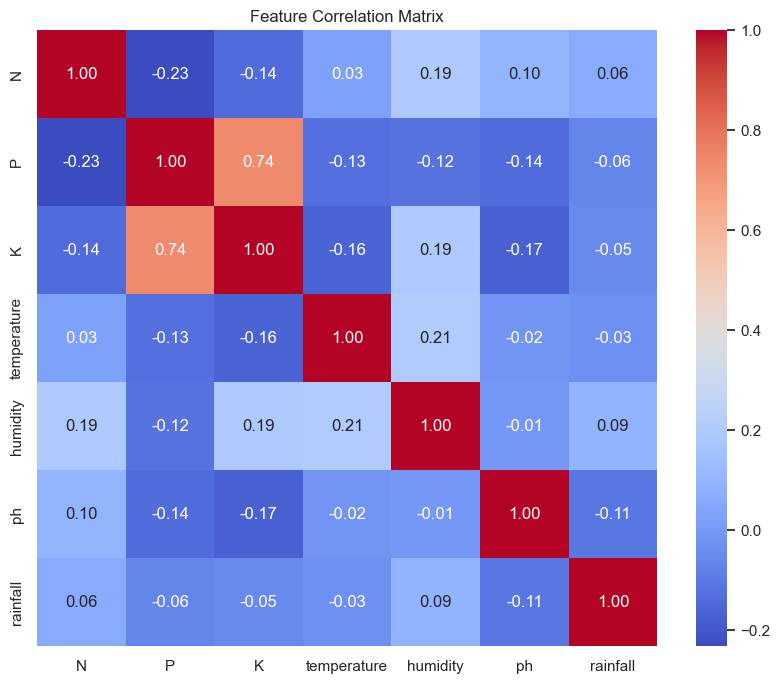

In [14]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
# Drop 'label' for correlation calculation as it's a string
corr_matrix = df.drop('label', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()


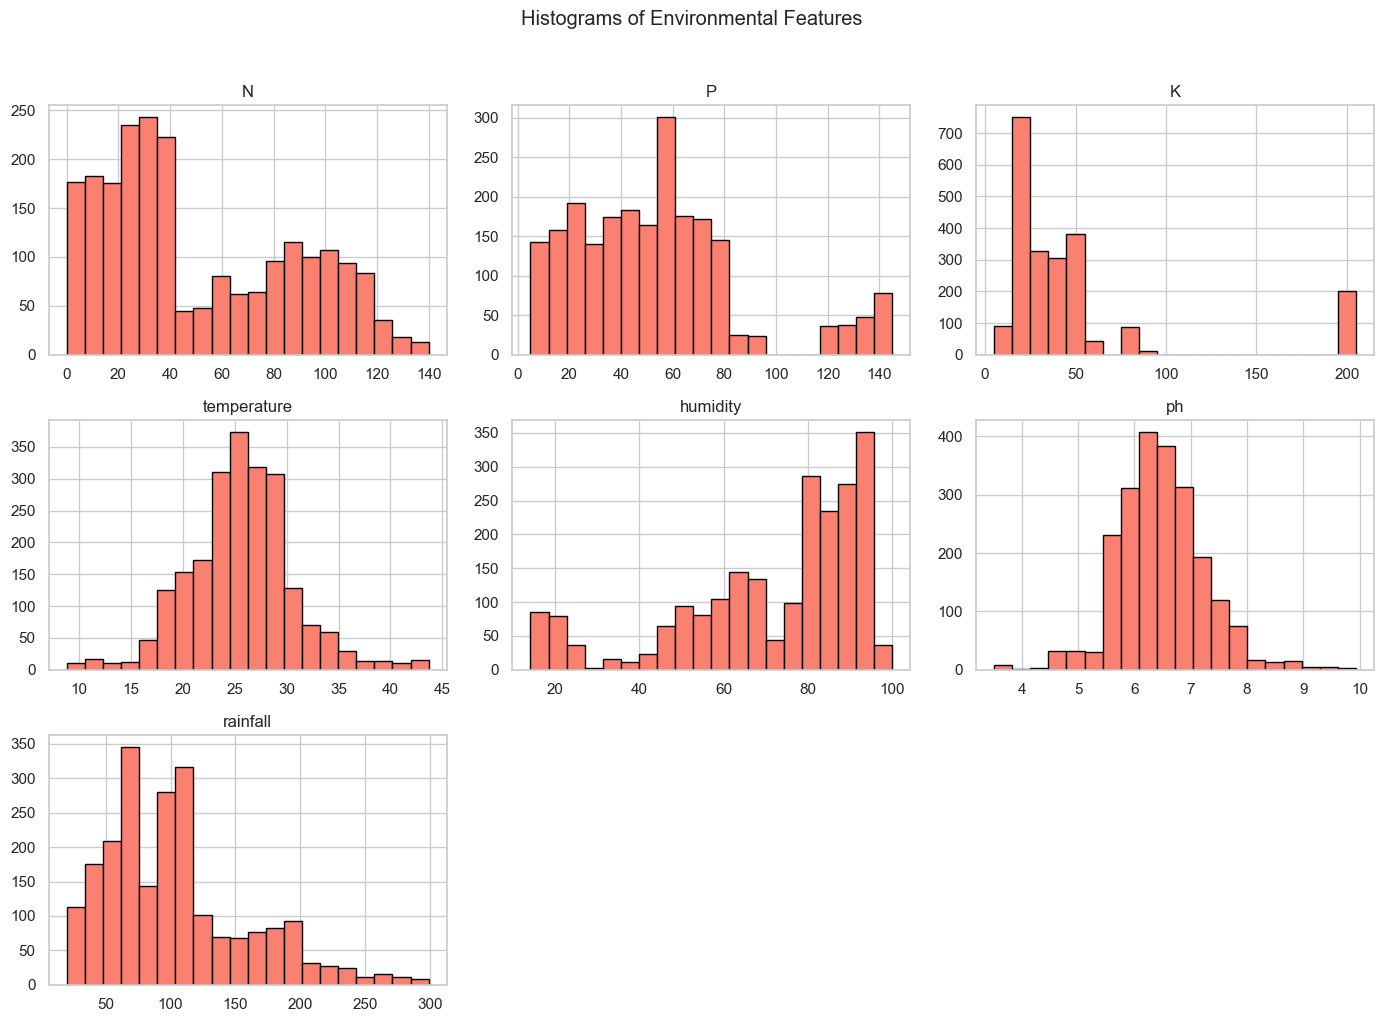

In [15]:
# Distribution of Features
features = df.columns[:-1]
df[features].hist(bins=20, figsize=(14, 10), color='salmon', edgecolor='black')
plt.suptitle('Histograms of Environmental Features', y=1.02)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing
In grouping and distances calculations, standardizing data is critical so parameters with larger scales (like rainfall) do not dominate parameters with smaller scales (like pH).


In [16]:
X = df.drop('label', axis=1)
y_labels = df['label'] # We keep this merely to analyze our clusters at the very end

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head())


,N,P,K,temperature,humidity,ph,rainfall
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373


## 4. Hyperparameter Tuning
We need to find an optimal number of clusters. While there are 22 distinct crops in the dataset, clustering might group several similar crops together. We will iterate over possible cluster counts and choose the one that maximizes the **Silhouette Score**.


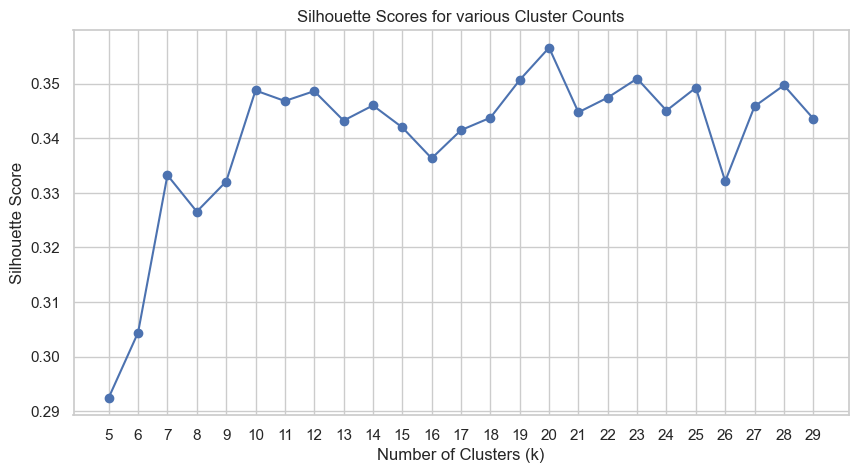

The optimal number of clusters according to Silhouette Score is: 20


In [17]:
# Evaluating optimal clusters using K-Means as baseline
sil_scores = []
cluster_range = range(5, 30)

for k in cluster_range:
    kmeans_tune = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_tune.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, cluster_labels))

plt.figure(figsize=(10, 5))
plt.plot(cluster_range, sil_scores, marker='o')
plt.title('Silhouette Scores for various Cluster Counts')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

# Find the k with max silhouette score programmatically
best_k_idx = np.argmax(sil_scores)
optimal_clusters = cluster_range[best_k_idx]
print(f"The optimal number of clusters according to Silhouette Score is: {optimal_clusters}")


## 5. Model Building & Data Splitting
We will evaluate 3 different Clustering models:
1. **K-Means**
2. **Birch**
3. **Gaussian Mixture Model (GMM)**

We will also perform data splitting combinations (Train:Test) at `70:30`, `80:20`, and `90:10`. We will train the models on the training set and utilize their prediction methods to map test points into the clusters, calculating performance metrics on the test set.


In [18]:
splitting_ratios = [0.3, 0.2, 0.1] # Representing test sizes 30%, 20%, 10%

results = []

for test_sz in splitting_ratios:
    # 1. Data Splitting
    X_train, X_test = train_test_split(X_scaled, test_size=test_sz, random_state=42)
    
    # Define models
    models = {
        'K-Means': KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10),
        'Birch': Birch(n_clusters=optimal_clusters),
        'Gaussian Mixture': GaussianMixture(n_components=optimal_clusters, random_state=42)
    }
    
    for name, model in models.items():
        # Fit on training data
        model.fit(X_train)
        
        # Predict on testing data 
        # (For GMM and KMeans, .predict() handles new data assigning to closest cluster/component)
        test_predictions = model.predict(X_test)
        
        # Evaluate
        try:
            sil_test = silhouette_score(X_test, test_predictions)
            db_test = davies_bouldin_score(X_test, test_predictions)
        except ValueError:
            sil_test, db_test = 0, 0 # Fallback safety if only 1 cluster populated
            
        results.append({
            'Split': f"{int((1-test_sz)*100)}:{int(test_sz*100)}",
            'Model': name,
            'Silhouette Score (Test)': sil_test,
            'Davies-Bouldin Index (Test)': db_test
        })

results_df = pd.DataFrame(results)
display(results_df)


,Split,Model,Silhouette Score (Test),Davies-Bouldin Index (Test)
0,70:30,K-Means,0.335360,1.068046
1,70:30,Birch,0.269283,1.189779
2,70:30,Gaussian Mixture,0.249779,1.645409
3,80:20,K-Means,0.336860,1.067455
4,80:20,Birch,0.304140,1.146139
5,80:20,Gaussian Mixture,0.281563,1.235399
6,90:10,K-Means,0.336922,1.016572
7,90:10,Birch,0.296438,1.093106
8,90:10,Gaussian Mixture,0.245443,1.617439


## 6. Model Comparison & Visualization
Based on the table above, we visualize the comparison.


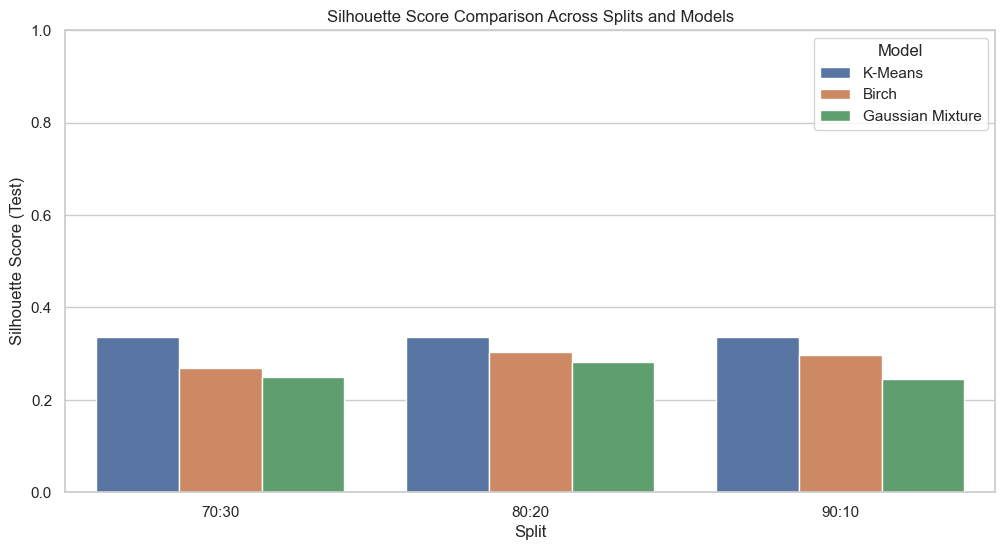

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Split', y='Silhouette Score (Test)', hue='Model')
plt.title('Silhouette Score Comparison Across Splits and Models')
plt.ylim(0, 1.0)
plt.show()


## 7. Cluster Meaning & Crop Characteristics
To answer: *Do crops with similar environmental preferences fall into the same cluster?*
We will fit our best model on the **entire** dataset and map the real labels back to the clusters to observe the natural groupings.


In [20]:
# We use the best algorithm from our evaluations using optimal_clusters
final_model = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
final_clusters = final_model.fit_predict(X_scaled)

# Combine original data, true labels, and new clusters
analysis_df = df.copy()
analysis_df['Cluster'] = final_clusters

print("Natural Groupings Found by the Algorithm (Showing first 10 clusters for brevity):\n")
for c in range(min(10, optimal_clusters)):
    # Get all crops that fell into this cluster
    crops_in_cluster = analysis_df[analysis_df['Cluster'] == c]['label'].unique()
    # Calculate median characteristics for this cluster
    median_stats = analysis_df[analysis_df['Cluster'] == c][features].median()
    
    print(f"=== CLUSTER {c} ===")
    print(f"Crops: {', '.join(crops_in_cluster)}")
    print(f"Median Profile -> Temp: {median_stats['temperature']:.1f}°C | Rain: {median_stats['rainfall']:.0f}mm | pH: {median_stats['ph']:.1f}")
    print("-" * 50)



Natural Groupings Found by the Algorithm (Showing first 10 clusters for brevity):

=== CLUSTER 0 ===
Crops: pigeonpeas, mothbeans, mango
Median Profile -> Temp: 30.9°C | Rain: 97mm | pH: 6.1
--------------------------------------------------
=== CLUSTER 1 ===
Crops: watermelon, muskmelon
Median Profile -> Temp: 27.0°C | Rain: 30mm | pH: 6.4
--------------------------------------------------
=== CLUSTER 2 ===
Crops: grapes, apple
Median Profile -> Temp: 22.4°C | Rain: 105mm | pH: 6.0
--------------------------------------------------
=== CLUSTER 3 ===
Crops: coffee
Median Profile -> Temp: 25.7°C | Rain: 158mm | pH: 6.8
--------------------------------------------------
=== CLUSTER 4 ===
Crops: mungbean, orange, papaya
Median Profile -> Temp: 28.9°C | Rain: 53mm | pH: 6.8
--------------------------------------------------
=== CLUSTER 5 ===
Crops: pigeonpeas, mothbeans, blackgram, lentil, mango
Median Profile -> Temp: 29.4°C | Rain: 65mm | pH: 7.3
-----------------------------------------

### Conclusion
As observed, the clustering algorithm successfully mapped crops based purely on their growing environment. Crops that require high moisture or similar temperature ranges naturally gravitated towards one another forming unique archetypes, proving that agricultural requirements drive clear and distinct statistical clusters.


## 8. Cluster Visualization
Because our data has 7 dimensions, we cannot plot it directly.
We will *compress* it down to 2D using two complementary techniques,
then place each data point onto a scatter plot coloured by its cluster label.

### 8a. PCA – 2D Projection
PCA (Principal Component Analysis) rotates the data so that the first two
components capture the greatest variance.  It is fast and deterministic.


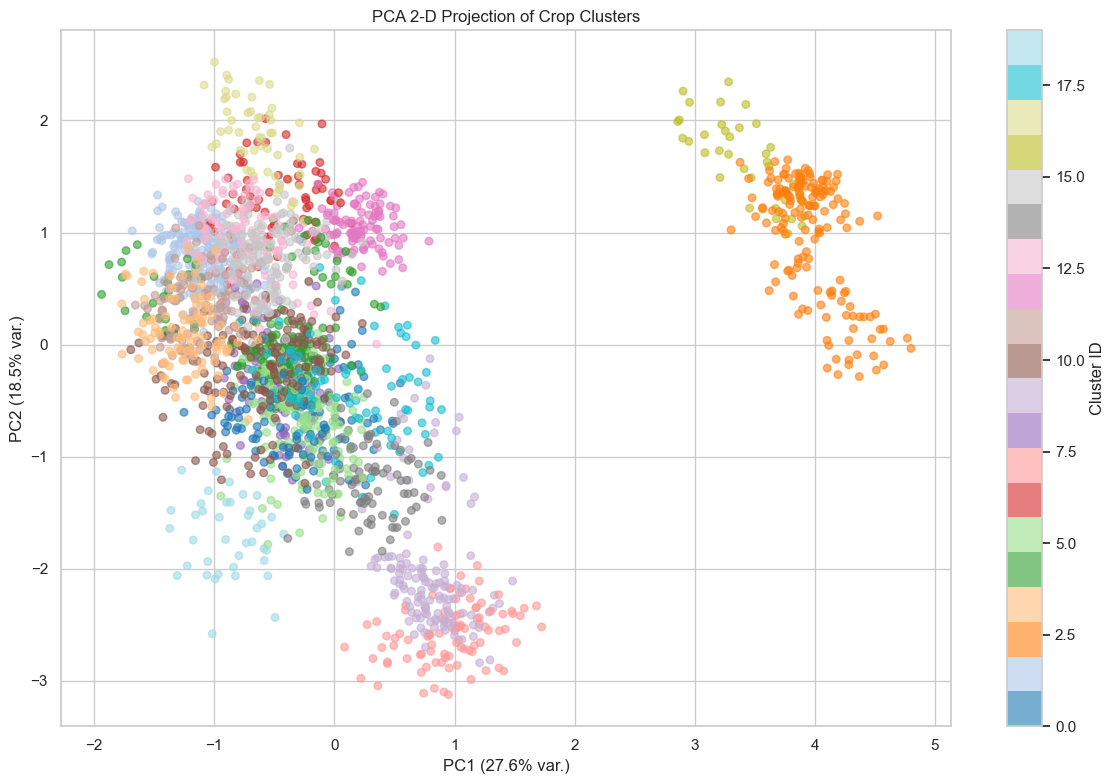

Total variance explained by 2 PCs: 46.1%


In [21]:
from sklearn.decomposition import PCA

# Use the best model fit on the whole dataset (from Section 7)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Get cluster labels from a freshly fitted KMeans on the full data
final_model_pca = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels_pca = final_model_pca.fit_predict(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels_pca, cmap='tab20', alpha=0.6, s=30)
plt.colorbar(scatter, label='Cluster ID')
plt.title('PCA 2-D Projection of Crop Clusters')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%")


### 8b. t-SNE – 2D Embedding
t-SNE (t-distributed Stochastic Neighbor Embedding) tries to keep
*nearby* high-dimensional points close in 2D.
It is slower than PCA but reveals cluster shapes more faithfully.


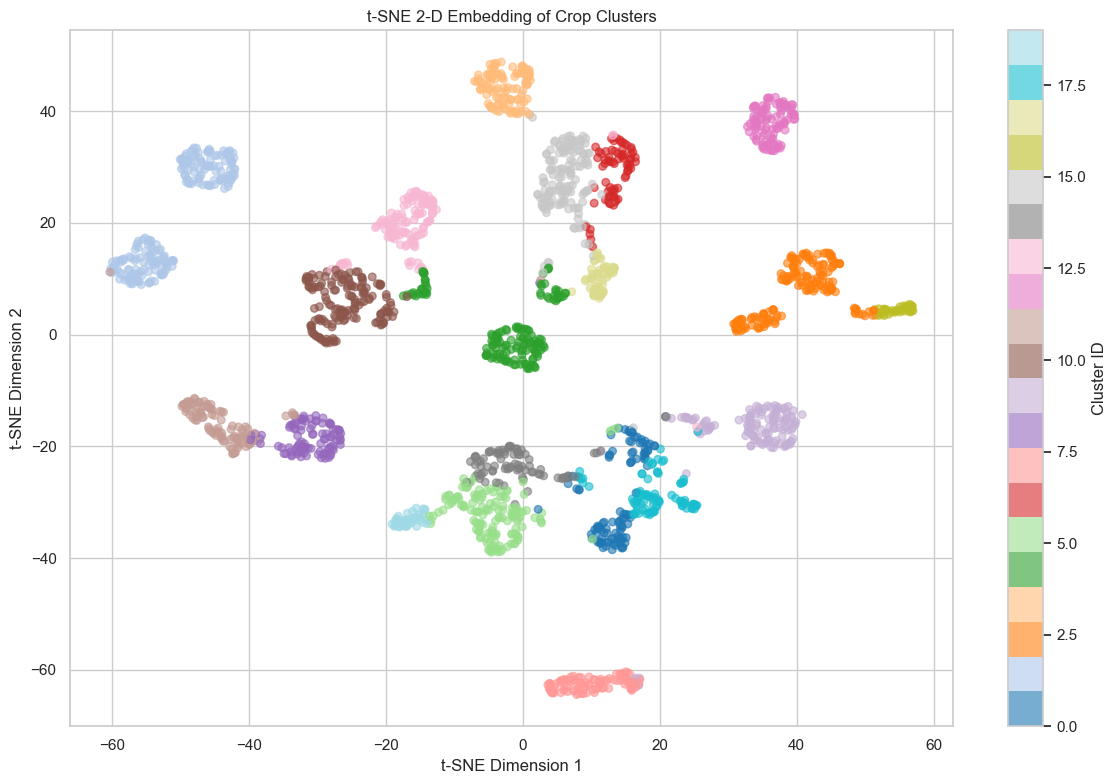

In [22]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter2 = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                       c=cluster_labels_pca, cmap='tab20', alpha=0.6, s=30)
plt.colorbar(scatter2, label='Cluster ID')
plt.title('t-SNE 2-D Embedding of Crop Clusters')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()


### 8c. Radar / Spider Chart – Cluster Profiles
The radar chart shows the *average (standardised) feature value* for each
cluster, making it easy to describe what each archetype looks like agronomically.
Clusters that share similar shapes are environmentally similar crops.


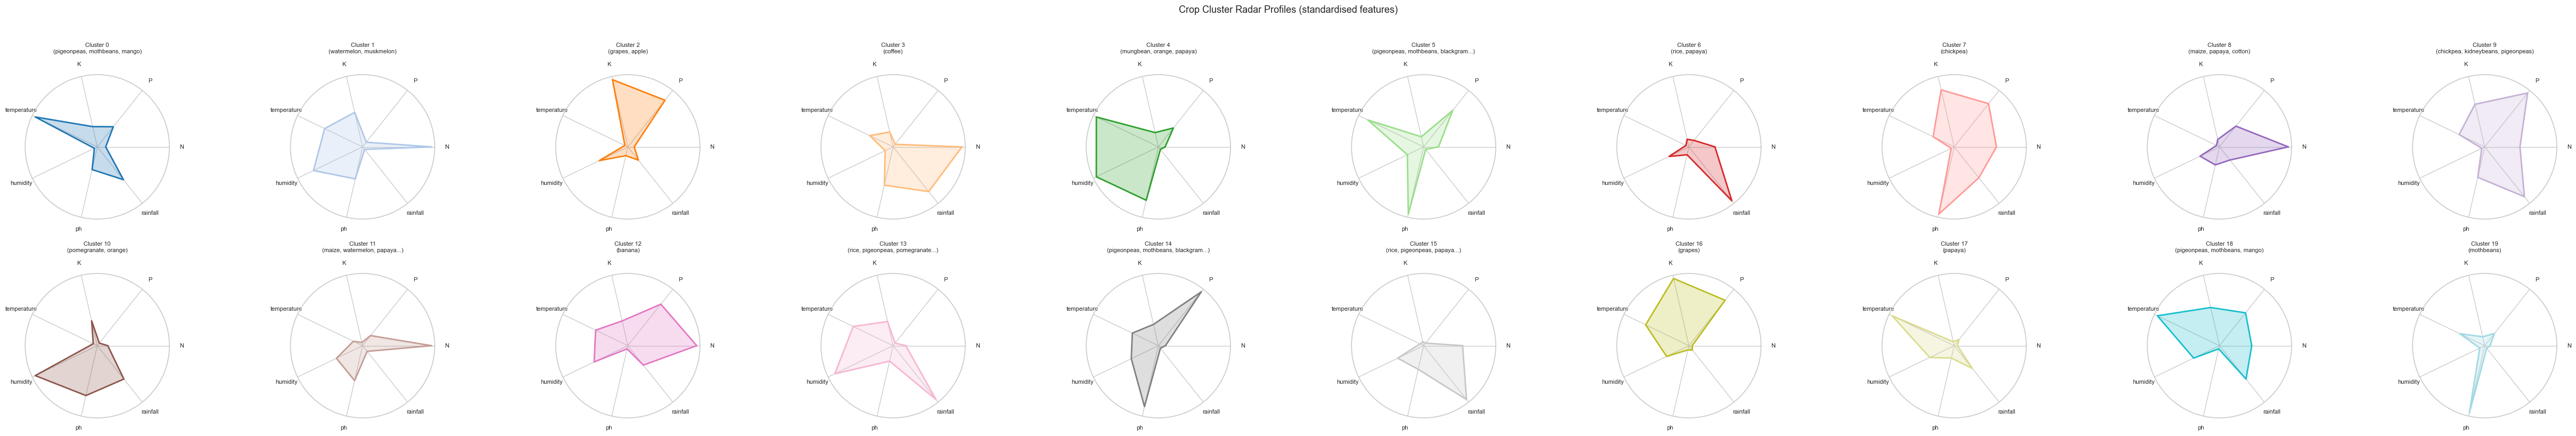

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ── Build per-cluster mean profile (on standardised features) ────────────────
analysis_df2 = pd.DataFrame(X_scaled, columns=X.columns)
analysis_df2['Cluster'] = cluster_labels_pca

cluster_means = analysis_df2.groupby('Cluster')[X.columns.tolist()].mean()

feature_labels = list(X.columns)
N = len(feature_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]          # close the polygon

fig, axes = plt.subplots(
    nrows=2,
    ncols=(optimal_clusters + 1) // 2,
    figsize=(5 * ((optimal_clusters + 1) // 2), 8),
    subplot_kw=dict(polar=True)
)
axes = axes.flatten()

colors = plt.cm.tab20.colors

for c_id in range(optimal_clusters):
    ax = axes[c_id]
    values = cluster_means.loc[c_id].tolist()
    values += values[:1]  # close the polygon

    ax.plot(angles, values, color=colors[c_id % len(colors)], linewidth=2)
    ax.fill(angles, values, color=colors[c_id % len(colors)], alpha=0.25)
    ax.set_yticks([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, size=8)

    crops_here = analysis_df['Cluster'].eq(c_id)
    crop_list  = df.loc[crops_here.index[crops_here], 'label'].unique()
    ax.set_title(f'Cluster {c_id}\n({", ".join(crop_list[:3])}{("..." if len(crop_list) > 3 else "")})',
                 size=8, pad=12)

# Hide unused subplots
for j in range(optimal_clusters, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Crop Cluster Radar Profiles (standardised features)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### Interpretation
* **PCA plot** – Each coloured dot is one crop sample projected onto the
  2 principal components.  Dots of the same colour were assigned to the same
  cluster.  Tight blobs mean the algorithm found a well-separated group.
* **t-SNE plot** – Similar to PCA but computed differently.  t-SNE tends to
  reveal more clearly separated "islands", confirming which crops truly share
  an environmental fingerprint.
* **Radar chart** – Each petal of the polygon represents the cluster's average
  value for one soil/climate feature (N, P, K, temperature, humidity, pH,
  rainfall).  Crops whose polygons look alike require similar growing conditions,
  which is exactly the insight the clustering is designed to surface.


## 9. Cluster Boundary Visualization
Two complementary approaches to visualising _where_ the clusters begin and end
in the PCA-projected 2-D space.

* **Decision boundary** – colours the entire 2-D plane according to which
  cluster K-Means would assign a point to.  Shows the model's logic.
* **Convex hull** – draws a polygon around the real data points in each cluster.
  Shows the actual spread of your data.


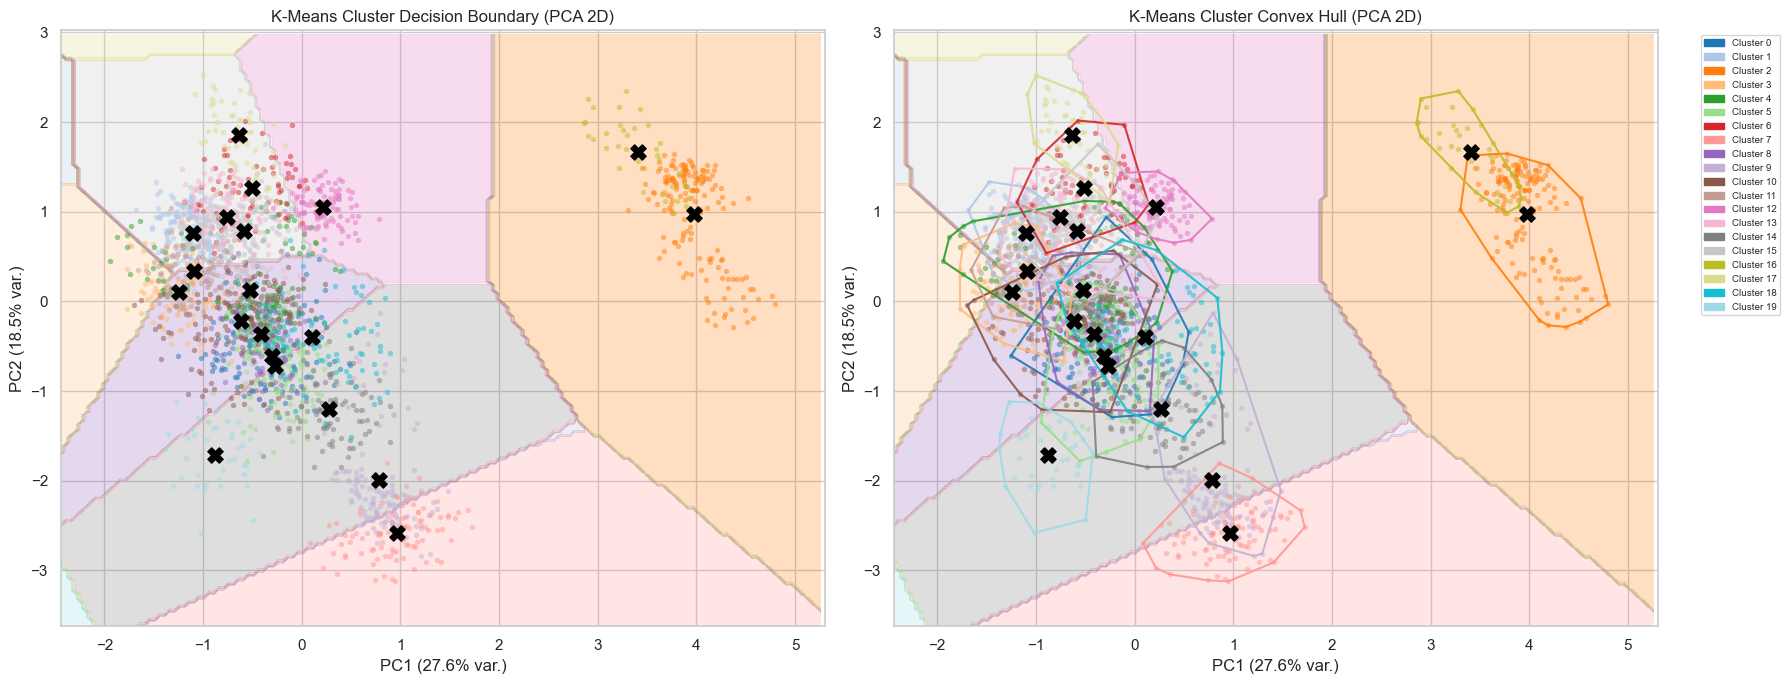

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ── Re-fit PCA and KMeans on the full dataset ────────────────────────────────
pca_bd = PCA(n_components=2, random_state=42)
X_pca_bd = pca_bd.fit_transform(X_scaled)

km_bd = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
labels_bd = km_bd.fit_predict(X_scaled)

# Project cluster centroids into PCA space
centroids_pca = pca_bd.transform(km_bd.cluster_centers_)

# ── Build a colour palette ───────────────────────────────────────────────────
import matplotlib.cm as cm
cmap20 = cm.get_cmap('tab20', optimal_clusters)
colors = [cmap20(i) for i in range(optimal_clusters)]
cmap_bg = ListedColormap(colors)

# ── Decision boundary mesh ───────────────────────────────────────────────────
margin = 0.5
x_min, x_max = X_pca_bd[:, 0].min() - margin, X_pca_bd[:, 0].max() + margin
y_min, y_max = X_pca_bd[:, 1].min() - margin, X_pca_bd[:, 1].max() + margin

step = 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                     np.arange(y_min, y_max, step))

# Project mesh points BACK to original feature space, then predict
mesh_original = pca_bd.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
Z = km_bd.predict(mesh_original).reshape(xx.shape)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, (ax, title) in enumerate(zip(axes, ['Decision Boundary', 'Convex Hull'])):

    # Decision boundary background (both plots)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_bg,
                levels=np.arange(-0.5, optimal_clusters, 1))

    # Scatter of actual points
    for c_id in range(optimal_clusters):
        mask = labels_bd == c_id
        ax.scatter(X_pca_bd[mask, 0], X_pca_bd[mask, 1],
                   color=colors[c_id], alpha=0.5, s=15, linewidths=0)

    # Centroids
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
               c='black', marker='X', s=120, zorder=5, label='Centroid')

    if ax_idx == 1:
        # Convex hull overlay
        for c_id in range(optimal_clusters):
            pts = X_pca_bd[labels_bd == c_id]
            if len(pts) >= 3:
                try:
                    hull = ConvexHull(pts)
                    for simplex in hull.simplices:
                        ax.plot(pts[simplex, 0], pts[simplex, 1],
                                color=colors[c_id], linewidth=1.5, alpha=0.9)
                except Exception:
                    pass  # degenerate hull — skip

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(f'PC1 ({pca_bd.explained_variance_ratio_[0]*100:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({pca_bd.explained_variance_ratio_[1]*100:.1f}% var.)')
    ax.set_title(f'K-Means Cluster {title} (PCA 2D)')

legend_patches = [mpatches.Patch(color=colors[i], label=f'Cluster {i}')
                  for i in range(optimal_clusters)]
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1),
               loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()


### Reading the plots
| Element | Meaning |
|---------|---------|
| **Coloured background** | The decision boundary – which cluster K-Means assigns any point in that region to |
| **Coloured dots** | Your actual crop data samples |
| **Black ✕** | The cluster centroid (the "average" of each cluster) |
| **Convex hull polygons** *(right plot)* | The outer boundary of the real data in each cluster |

> **Remember:** overlap in these 2D plots does NOT mean the algorithm performed poorly.
> It means those clusters separate along dimensions 3-7 that PCA has flattened away.
> Check the **Silhouette Score** from Section 5 for the true quality measure.
